In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from smarts_cerebellum import predictors_df as pred_df
import smarts_cerebellum.globals as gl

In [2]:
p_df = pd.read_csv(os.path.join(gl.baseDir, 'participants.tsv'), sep = '\t')
controls = p_df[p_df.isPatient == 0]
atlas = 'Nettekoven_2024'
maps = 'atl-NettekovenSym32'
segment = 'GM_mod'
folder = 'MNISymC_GM'

In [3]:
df = pred_df.response_df(controls,
                     folder = folder,
                     space = 'MNISymC',
                     atlas_space = 'MNISym', # if using atlas and maps, set MNISym, etc. Otherwise, default is same as space (MNISymC)
                     segment = segment,
                     stats = ['mean'],
                     label_image = None,
                     region_names = None,
                     atlas = atlas,
                     maps = maps,
                     )

In [4]:
df[(df.subj_id == 'CUP_1001') & (df.regionname.str.contains("M"))]

,image,image_name,frame,region,regionname,volume,atlas,map,space,mean,subj_id,Week
0,1,CUP_1001_W0_MNISymC_GM_mod.nii.gz,0,1,M1L,1652.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.593435,CUP_1001,0
1,1,CUP_1001_W0_MNISymC_GM_mod.nii.gz,0,2,M2L,6578.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.649448,CUP_1001,0
2,1,CUP_1001_W0_MNISymC_GM_mod.nii.gz,0,3,M3L,7296.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.607478,CUP_1001,0
3,1,CUP_1001_W0_MNISymC_GM_mod.nii.gz,0,4,M4L,3542.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.716076,CUP_1001,0
16,1,CUP_1001_W0_MNISymC_GM_mod.nii.gz,0,17,M1R,1385.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.608754,CUP_1001,0
17,1,CUP_1001_W0_MNISymC_GM_mod.nii.gz,0,18,M2R,5968.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.677117,CUP_1001,0
18,1,CUP_1001_W0_MNISymC_GM_mod.nii.gz,0,19,M3R,7296.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.647685,CUP_1001,0
19,1,CUP_1001_W0_MNISymC_GM_mod.nii.gz,0,20,M4R,3536.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.672653,CUP_1001,0
32,2,CUP_1001_W4_MNISymC_GM_mod.nii.gz,0,1,M1L,1652.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.642809,CUP_1001,4
33,2,CUP_1001_W4_MNISymC_GM_mod.nii.gz,0,2,M2L,6578.0,Nettekoven_2024,atl-NettekovenSym32,MNISym,0.691091,CUP_1001,4


In [5]:
send_help = ['M2L', 'M2R']
new = df[df.regionname.str.contains('M2')]
new['hemisphere'] = new.regionname.str[2]

/localscratch/tmp/ipykernel_24467/4009983133.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new['hemisphere'] = new.regionname.str[2]


In [6]:
exclude = 'UZP_1007'
exclusion = new[~(new.subj_id == exclude)]

In [7]:
display(new.subj_id.unique())
display(exclusion.subj_id.unique())

array(['CUP_1001', 'JHP_1001', 'JHP_1002', 'UZP_1001', 'UZP_1002',
       'UZP_1004', 'UZP_1005', 'UZP_1006', 'UZP_1007', 'UZP_1008'],
      dtype=object)

array(['CUP_1001', 'JHP_1001', 'JHP_1002', 'UZP_1001', 'UZP_1002',
       'UZP_1004', 'UZP_1005', 'UZP_1006', 'UZP_1008'], dtype=object)

UZP_1005, UZP_1007

<Axes: xlabel='Week', ylabel='mean'>

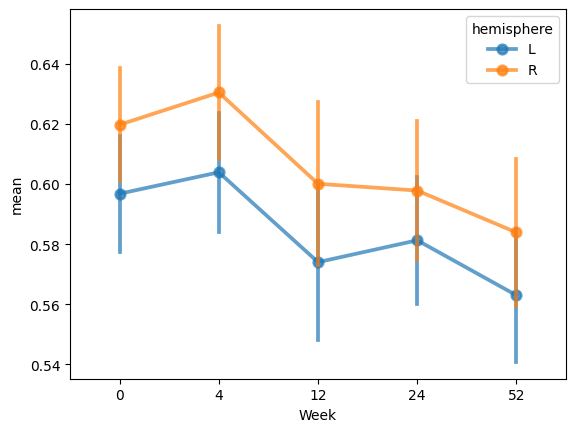

In [8]:
sns.pointplot(data = exclusion, x = 'Week', y = 'mean', hue = 'hemisphere', alpha = .7, errorbar = 'se')

<Axes: xlabel='Week', ylabel='mean'>

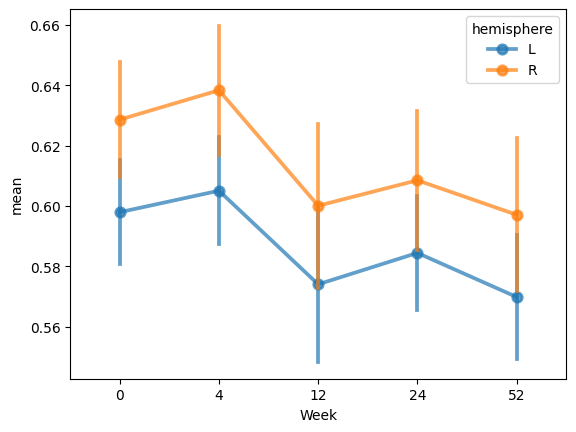

In [9]:
sns.pointplot(data = new, x = 'Week', y = 'mean', hue = 'hemisphere', alpha = .7, errorbar = 'se')

In [10]:
from scipy import stats
import numpy as np

for week in new.Week.unique():
    l = np.array(new[(new.Week == week) & (new.hemisphere == 'L')]['mean'])
    r = np.array(new[(new.Week == week) & (new.hemisphere == 'R')]['mean'])

    t, p = stats.ttest_rel(l,r)
    print(f'week {week}: \n t = {t}, p = {p}')

week 0: 
 t = -3.240046764188355, p = 0.010157897450586059
week 4: 
 t = -3.0751477980957023, p = 0.01324337184642687
week 12: 
 t = -3.057191693651258, p = 0.02230517587742781
week 24: 
 t = -2.432084494905232, p = 0.04106847910948749
week 52: 
 t = -2.779662609031294, p = 0.02393702006024643
